# Student Academic Risk Prediction

Using the Student Performance data set, predict whether a student is at risk (`G3 < 10`). The primary concern is missing an ‘at-risk’ student, thus recall has been chosen as the main indicator.

In [20]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, f1_score,
    precision_score, recall_score
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

## 1. Load the dataset

In [21]:
# Set CSV_PATH to a local file, or leave it as None to use KaggleHub.
CSV_PATH = None  # Example: "data/student_data.csv"

if CSV_PATH:
    df = pd.read_csv(CSV_PATH)
else:
    import kagglehub

    dataset_path = Path(kagglehub.dataset_download(
        "devansodariya/student-performance-data"
    ))
    csv_files = list(dataset_path.rglob("*.csv"))
    if len(csv_files) != 1:
        raise FileNotFoundError(f"Expected one CSV, found: {csv_files}")
    df = pd.read_csv(csv_files[0])
    print(f"Loaded: {csv_files[0]}")

required = {"G1", "G2", "G3"}
if missing := required - set(df.columns):
    raise ValueError(f"Missing required columns: {sorted(missing)}")

df.head()

Loaded: /Users/bklcross/.cache/kagglehub/datasets/devansodariya/student-performance-data/versions/1/student_data.csv


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## 2. Explore the data and create the target

In [22]:
print(f"Rows: {len(df)}, columns: {len(df.columns)}")
display(df.dtypes.rename("data type").to_frame())
display(df.isna().sum().rename("missing values").to_frame())
display(df[["G1", "G2", "G3"]].describe())

df["at_risk"] = (df["G3"] < 10).astype(int)
class_balance = df["at_risk"].map({0: "not at risk", 1: "at risk"}).value_counts()
display(class_balance.rename("students").to_frame())

Rows: 395, columns: 33


,data type
school,object
sex,object
age,int64
address,object
famsize,object
Pstatus,object
Medu,int64
Fedu,int64
Mjob,object
Fjob,object


,missing values
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


,G1,G2,G3
count,395.000000,395.000000,395.000000
mean,10.908861,10.713924,10.415190
std,3.319195,3.761505,4.581443
min,3.000000,0.000000,0.000000
25%,8.000000,9.000000,8.000000
50%,11.000000,11.000000,11.000000
75%,13.000000,13.000000,14.000000
max,19.000000,19.000000,20.000000


,students
at_risk,
not at risk,265
at risk,130


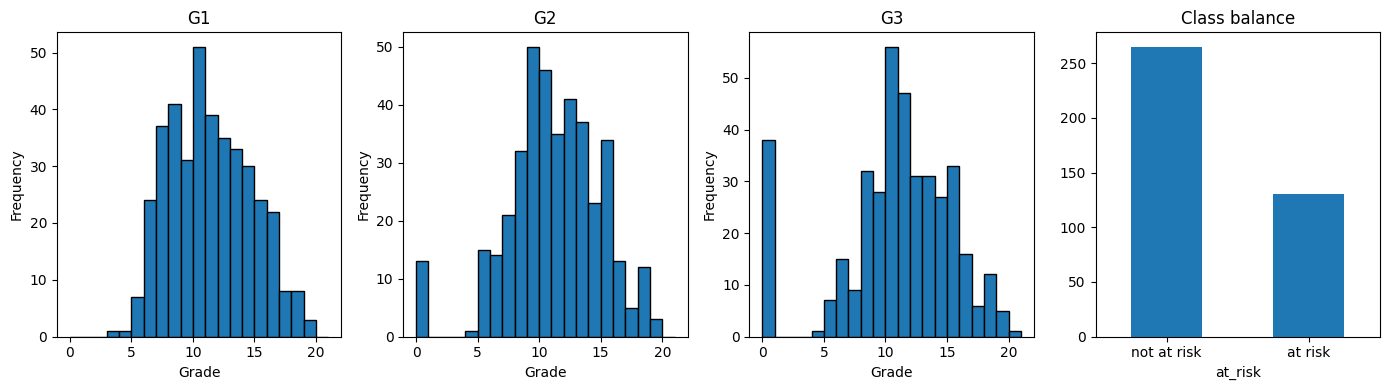

In [23]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, grade in zip(axes[:3], ["G1", "G2", "G3"]):
    df[grade].plot.hist(ax=ax, bins=range(22), edgecolor="black", title=grade)
    ax.set_xlabel("Grade")
class_balance.plot.bar(ax=axes[3], title="Class balance", rot=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "data_overview.png", dpi=150)
plt.show()

## 3. Prepare feature sets and models

In [24]:
y = df["at_risk"]
X_full = df.drop(columns=["G3", "at_risk"])
feature_sets = {
    "Includes G1/G2": X_full,
    "Excludes G1/G2": X_full.drop(columns=["G1", "G2"]),
}

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

## 4. Train and compare models

In [25]:
results, fitted = [], {}

for feature_name, X in feature_sets.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
    )
    numeric = X.select_dtypes(include="number").columns
    categorical = X.select_dtypes(exclude="number").columns
    preprocessor = ColumnTransformer([
        ("numeric", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), numeric),
        ("categorical", make_pipeline(
            SimpleImputer(strategy="most_frequent"),
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
        ), categorical),
    ])

    for model_name, model in models.items():
        pipeline = make_pipeline(preprocessor, clone(model))
        pipeline.fit(X_train, y_train)
        prediction = pipeline.predict(X_test)
        results.append({
            "feature_set": feature_name,
            "model": model_name,
            "accuracy": accuracy_score(y_test, prediction),
            "precision": precision_score(y_test, prediction, zero_division=0),
            "recall": recall_score(y_test, prediction, zero_division=0),
            "f1": f1_score(y_test, prediction, zero_division=0),
        })
        fitted[(feature_name, model_name)] = (pipeline, y_test, prediction)

results = pd.DataFrame(results).sort_values(["recall", "f1"], ascending=False)
results.to_csv(OUTPUT_DIR / "model_results.csv", index=False)
results

,feature_set,model,accuracy,precision,recall,f1
2,Includes G1/G2,Random Forest,0.909091,0.852941,0.878788,0.865672
3,Includes G1/G2,Gradient Boosting,0.909091,0.852941,0.878788,0.865672
1,Includes G1/G2,Decision Tree,0.888889,0.805556,0.878788,0.840580
0,Includes G1/G2,Logistic Regression,0.868687,0.763158,0.878788,0.816901
4,Excludes G1/G2,Logistic Regression,0.666667,0.500000,0.545455,0.521739
5,Excludes G1/G2,Decision Tree,0.616162,0.428571,0.454545,0.441176
7,Excludes G1/G2,Gradient Boosting,0.686869,0.555556,0.303030,0.392157
6,Excludes G1/G2,Random Forest,0.686869,0.600000,0.181818,0.279070


## 5. Evaluate the best model

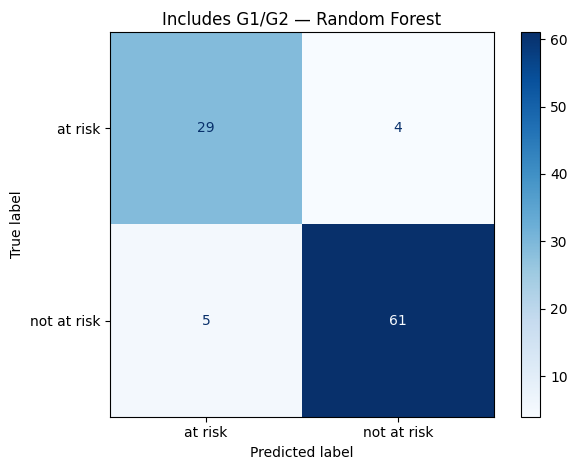

feature_set    Includes G1/G2
model           Random Forest
accuracy             0.909091
precision            0.852941
recall               0.878788
f1                   0.865672
Name: 2, dtype: object

In [26]:
# Highest recall wins; F1 breaks ties.
best = results.iloc[0]
pipeline, y_test, prediction = fitted[(best["feature_set"], best["model"])]

ConfusionMatrixDisplay.from_predictions(
    y_test, prediction, labels=[1, 0],
    display_labels=["at risk", "not at risk"], cmap="Blues"
)
plt.title(f"{best['feature_set']} — {best['model']}")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=150)
plt.show()
best

## 6. Important predictive features

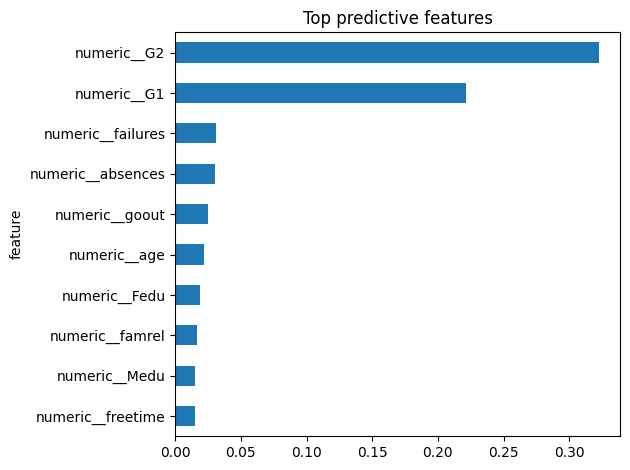

,feature,importance
14,numeric__G2,0.322461
13,numeric__G1,0.221388
5,numeric__failures,0.031213
12,numeric__absences,0.030012
8,numeric__goout,0.024873
0,numeric__age,0.021663
2,numeric__Fedu,0.019118
6,numeric__famrel,0.016969
1,numeric__Medu,0.015281
7,numeric__freetime,0.015013


In [27]:
preprocessor, model = pipeline.steps[0][1], pipeline.steps[1][1]
feature_names = preprocessor.get_feature_names_out()
values = (
    model.feature_importances_ if hasattr(model, "feature_importances_")
    else np.abs(model.coef_[0])
)
importance = pd.DataFrame({"feature": feature_names, "importance": values})
importance = importance.sort_values("importance", ascending=False)
importance.to_csv(OUTPUT_DIR / "feature_importance.csv", index=False)

importance.head(10).iloc[::-1].plot.barh(
    x="feature", y="importance", legend=False, title="Top predictive features"
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "feature_importance.png", dpi=150)
plt.show()
importance.head(10)

## 7. Progress, limitations, and remaining work

The project started with the loading and exploration of real student records, where the binary class for risk was generated, four different classifiers were compared using two feature sets, and the major focus was towards recall.

The issues with this analysis include a small data set, limited population, sensitive characteristics of students, and use of one train/test split. The future work includes cross-validation of the model, tuning model parameters, and fairness and generalization tests before the forecasts can be used for student help.